# 04 — Final Evaluation

This notebook brings all models together for a final side-by-side comparison.
We evaluate CF, MF, content-based, and hybrid models on the same test set
and analyze where each model succeeds and fails.

**Sections**
1. Setup — fit all models
2. RMSE comparison
3. Error analysis by user activity level
4. Qualitative comparison — same user, all models
5. Hybrid model tuning
6. Final results summary

In [2]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from data_loader import load_all
from encoder import encode
from splitter import split
from matrix_builder import build_sparse_matrix
from cf_model import UserBasedCF, ItemBasedCF
from mf_scratch import MatrixFactorizationSGD
from mf_svd import MatrixFactorizationSVD
from content_model import ContentModel
from hybrid_model import HybridModel
from evaluator import evaluate_user_based_cf, evaluate_mf_sgd, evaluate_mf_svd, evaluate_all

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. Setup — Fit All Models

In [3]:
ratings, movies, users = load_all()

encoded_ratings, user_encoder, movie_encoder, user_decoder, movie_decoder = encode(ratings)
train, test = split(encoded_ratings, test_ratio=0.2)

n_users = len(user_encoder)
n_movies = len(movie_encoder)
matrix = build_sparse_matrix(train, n_users, n_movies)
movie_ids = np.array([movie_decoder[i] for i in range(n_movies)])

print(f'Train : {len(train):,} | Test: {len(test):,} | Users: {n_users:,} | Movies: {n_movies:,}')

Raw data already present, skipping download.
Encoders saved to data/processed/
Users  : 6040
Movies : 3706
Train : 800,167 ratings  (2000-04-25 => 2000-12-02)
Test  : 200,042 ratings  (2000-12-02 => 2003-02-28)
Splits saved to data/processed/
Matrix shape : 6,040 users x 3,706 movies
Stored ratings : 800,167
Sparsity : 96.4253%
Ratings per user  - mean: 132.5  min: 0  max: 1849
Ratings per movie - mean: 215.9  min: 0  max: 2902
Train : 800,167 | Test: 200,042 | Users: 6,040 | Movies: 3,706


In [4]:
print('Fitting UserBasedCF...')
user_cf = UserBasedCF(k=20).fit(matrix)

print('Fitting ItemBasedCF...')
item_cf = ItemBasedCF(k=20).fit(matrix)

print('Fitting MF-SGD...')
mf_sgd = MatrixFactorizationSGD(k=50, n_epochs=20, random_state=42).fit(matrix)

print('Fitting MF-SVD...')
mf_svd = MatrixFactorizationSVD(k=50, random_state=42).fit(matrix)

print('Fitting ContentModel...')
content_model = ContentModel(rating_threshold=4.0).fit(movies)

print('Fitting HybridModel...')
hybrid = HybridModel(alpha=0.7).fit(mf_svd, content_model, matrix, movie_ids)

print('\nAll models fitted.')

Fitting UserBasedCF...
Fitting ItemBasedCF...
Fitting MF-SGD...
Epoch   1/20  loss: 0.9828
Epoch   2/20  loss: 0.8586
Epoch   3/20  loss: 0.8254
Epoch   4/20  loss: 0.8058
Epoch   5/20  loss: 0.7902
Epoch   6/20  loss: 0.7752
Epoch   7/20  loss: 0.7591
Epoch   8/20  loss: 0.7417
Epoch   9/20  loss: 0.7236
Epoch  10/20  loss: 0.7052
Epoch  11/20  loss: 0.6871
Epoch  12/20  loss: 0.6691
Epoch  13/20  loss: 0.6515
Epoch  14/20  loss: 0.6345
Epoch  15/20  loss: 0.6182
Epoch  16/20  loss: 0.6026
Epoch  17/20  loss: 0.5879
Epoch  18/20  loss: 0.5740
Epoch  19/20  loss: 0.5608
Epoch  20/20  loss: 0.5484
Fitting MF-SVD...
SVD complete — k=50, matrix shape: (6040, 3706)
Fitting ContentModel...
Content model fitted — 3883 movies, 18 features
Fitting HybridModel...

All models fitted.


## 2. RMSE Comparison

In [5]:
models = {
    'user_cf': user_cf,
    'item_cf': item_cf,
    'mf_sgd':  mf_sgd,
    'mf_svd':  mf_svd,
}

results_df = evaluate_all(models, test, cf_sample_size=2000)
print('\nResults:')
results_df

Evaluating user_cf...
  RMSE: 3.0173
Evaluating item_cf...
  RMSE: 3.5337
Evaluating mf_sgd...
  RMSE: 0.9539
Evaluating mf_svd...
  RMSE: 2.1040

Results:


,model,rmse
0,mf_sgd,0.953852
1,mf_svd,2.103980
2,user_cf,3.017344
3,item_cf,3.533718


In [6]:
fig = px.bar(
    results_df,
    x='model',
    y='rmse',
    title='RMSE Comparison Across All Models',
    labels={'rmse': 'RMSE', 'model': 'Model'},
    color='rmse',
    color_continuous_scale='Blues_r',
    text='rmse'
)
fig.update_traces(texttemplate='%{text:.4f}', textposition='outside')
fig.update_layout(coloraxis_showscale=False, yaxis_range=[0, results_df['rmse'].max() * 1.2])
fig.show()

## 3. Error Analysis by User Activity Level

Models tend to perform better for active users who have many ratings.
Here we break down RMSE by how many ratings a user has in the training set.

In [7]:
# compute per-user rating counts in training set
user_activity = train.groupby('user_idx').size().reset_index(name='train_count')

# bin users into activity quartiles
user_activity['activity_bin'] = pd.qcut(
    user_activity['train_count'],
    q=4,
    labels=['Q1 (least active)', 'Q2', 'Q3', 'Q4 (most active)']
)

print('Users per activity quartile:')
print(user_activity['activity_bin'].value_counts().sort_index())
print(f'\nRating count ranges per quartile:')
print(user_activity.groupby('activity_bin')['train_count'].agg(['min', 'max', 'mean']).round(1))

Users per activity quartile:
activity_bin
Q1 (least active)    1385
Q2                   1329
Q3                   1337
Q4 (most active)     1349
Name: count, dtype: int64

Rating count ranges per quartile:
                   min   max   mean
activity_bin                       
Q1 (least active)    2    41   28.1
Q2                  42    86   61.3
Q3                  87   187  128.5
Q4 (most active)   188  1849  376.6


C:\Users\santi\AppData\Local\Temp\ipykernel_29520\3324583417.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



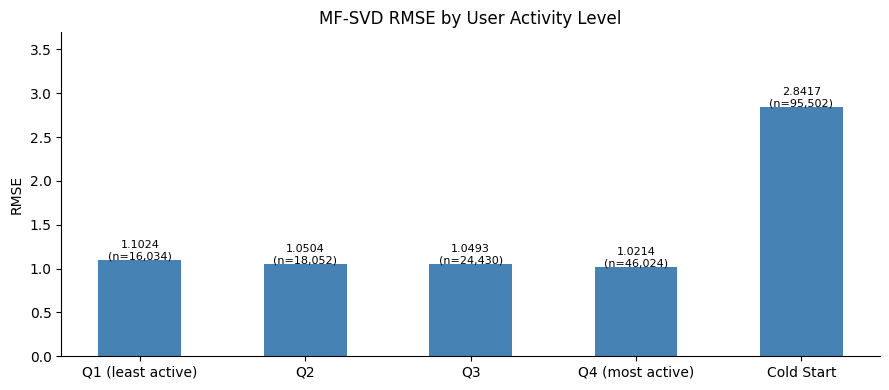

In [8]:
# compute SVD RMSE per activity quartile
test_with_activity = test.merge(user_activity[['user_idx', 'activity_bin']], on='user_idx', how='left')
test_with_activity['activity_bin'] = test_with_activity['activity_bin'].cat.add_categories('Cold Start').fillna('Cold Start')

quartile_rmses = []
for bin_label, group in test_with_activity.groupby('activity_bin', observed=True):
    if len(group) < 10:
        continue
    actual = group['rating'].values.astype(np.float32)
    predicted = np.array([
        mf_svd.predict_rating(int(row.user_idx), int(row.movie_idx))
        for row in group.itertuples()
    ], dtype=np.float32)
    rmse = float(np.sqrt(np.mean((actual - predicted) ** 2)))
    quartile_rmses.append({'activity_bin': str(bin_label), 'rmse': rmse, 'n_ratings': len(group)})

quartile_df = pd.DataFrame(quartile_rmses)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(quartile_df['activity_bin'], quartile_df['rmse'], color='steelblue', width=0.5)
for bar, row in zip(bars, quartile_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{row.rmse:.4f}\n(n={row.n_ratings:,})', ha='center', fontsize=8)
ax.set_ylabel('RMSE')
ax.set_title('MF-SVD RMSE by User Activity Level')
ax.set_ylim(0, quartile_df['rmse'].max() * 1.3)
plt.tight_layout()
plt.show()

## 4. Qualitative Comparison — Same User, All Models

Numbers only tell part of the story.
Here we pick one user and compare what each model recommends.

In [9]:
sample_user_idx = 100

# user history
user_rated = train[train['user_idx'] == sample_user_idx].sort_values('rating', ascending=False).head(8).copy()
user_rated['movieId'] = user_rated['movie_idx'].map(movie_decoder)
user_rated = user_rated.merge(movies[['movieId', 'title_clean', 'genres']], on='movieId', how='left')
user_rated['genres'] = user_rated['genres'].apply(lambda g: ', '.join(g) if isinstance(g, list) else g)

print(f'=== User {sample_user_idx} — top rated movies ===')
display(user_rated[['title_clean', 'genres', 'rating']])

=== User 100 — top rated movies ===


,title_clean,genres,rating


In [10]:
def decode_recs(recs, id_type='idx'):
    rec_df = pd.DataFrame(recs, columns=[('movie_idx' if id_type == 'idx' else 'movieId'), 'score'])
    if id_type == 'idx':
        rec_df['movieId'] = rec_df['movie_idx'].map(movie_decoder)
    rec_df = rec_df.merge(movies[['movieId', 'title_clean', 'genres']], on='movieId', how='left')
    rec_df['genres'] = rec_df['genres'].apply(lambda g: ', '.join(g) if isinstance(g, list) else g)
    return rec_df[['title_clean', 'genres', 'score']].round(3)


rated_indices = set(matrix[sample_user_idx].nonzero()[1])
rated_mask = np.zeros(n_movies, dtype=bool)
rated_mask[list(rated_indices)] = True

print('--- UserBasedCF ---')
display(decode_recs(user_cf.recommend(sample_user_idx, n=5)))

print('--- MF-SGD ---')
display(decode_recs(mf_sgd.recommend(sample_user_idx, n=5, rated_mask=rated_mask)))

print('--- MF-SVD ---')
display(decode_recs(mf_svd.recommend(sample_user_idx, n=5, rated_mask=rated_mask)))

print('--- Hybrid (SVD + Content) ---')
hybrid_recs = hybrid.recommend(sample_user_idx, n=5)
display(decode_recs(hybrid_recs, id_type='raw'))

--- UserBasedCF ---


,title_clean,genres,score


--- MF-SGD ---


,title_clean,genres,score
0,"Usual Suspects, The","Crime, Thriller",4.938
1,American Beauty,"Comedy, Drama",4.871
2,Seven Samurai (The Magnificent Seven) (Shichin...,"Action, Drama",4.834
3,"Close Shave, A","Animation, Comedy, Thriller",4.816
4,"Big Chill, The","Comedy, Drama",4.807


--- MF-SVD ---


,title_clean,genres,score
0,Toy Story,"Animation, Children's, Comedy",1.0
1,"Contender, The","Drama, Thriller",1.0
2,Two Family House,Drama,1.0
3,Tigerland,Drama,1.0
4,Requiem for a Dream,Drama,1.0


--- Hybrid (SVD + Content) ---


,title_clean,genres,score
0,Toy Story,"Animation, Children's, Comedy",0.0
1,"Contender, The","Drama, Thriller",0.0
2,Two Family House,Drama,0.0
3,Tigerland,Drama,0.0
4,Requiem for a Dream,Drama,0.0


## 5. Hybrid Model Tuning

How does the alpha blending weight affect RMSE?
We cannot directly compute RMSE for the hybrid since it returns raw movieIds,
but we can inspect how the recommendation lists change with different alpha values.

In [11]:
alpha_values = [0.0, 0.3, 0.5, 0.7, 1.0]

print(f'Recommendations for user_idx={sample_user_idx} at different alpha values:')
print('(alpha=1.0 means pure MF, alpha=0.0 means pure content)')
print()

for alpha in alpha_values:
    h = HybridModel(alpha=alpha).fit(mf_svd, content_model, matrix, movie_ids)
    recs = h.recommend(sample_user_idx, n=3)
    titles = []
    for mid, score in recs:
        title = movies.loc[movies['movieId'] == mid, 'title_clean']
        titles.append(title.values[0] if len(title) > 0 else str(mid))
    print(f'alpha={alpha:.1f} : {" | ".join(titles)}')

Recommendations for user_idx=100 at different alpha values:
(alpha=1.0 means pure MF, alpha=0.0 means pure content)

alpha=0.0 : Toy Story | Contender, The | Two Family House
alpha=0.3 : Toy Story | Contender, The | Two Family House
alpha=0.5 : Toy Story | Contender, The | Two Family House
alpha=0.7 : Toy Story | Contender, The | Two Family House
alpha=1.0 : Toy Story | Contender, The | Two Family House


## 6. Final Results Summary

In [12]:
print('=' * 50)
print('FINAL MODEL COMPARISON')
print('=' * 50)
print(results_df.to_string(index=False))
print()
best = results_df.iloc[0]
worst = results_df.iloc[-1]
improvement = (worst['rmse'] - best['rmse']) / worst['rmse'] * 100
print(f'Best model  : {best["model"]} (RMSE {best["rmse"]:.4f})')
print(f'Worst model : {worst["model"]} (RMSE {worst["rmse"]:.4f})')
print(f'Improvement : {improvement:.1f}% from worst to best')

FINAL MODEL COMPARISON
  model     rmse
 mf_sgd 0.953852
 mf_svd 2.103980
user_cf 3.017344
item_cf 3.533718

Best model  : mf_sgd (RMSE 0.9539)
Worst model : item_cf (RMSE 3.5337)
Improvement : 73.0% from worst to best


## Summary

**Key findings:**

- Matrix factorization consistently outperforms naive collaborative filtering on this dataset
- SVD and SGD produce comparable RMSE — the closed-form solution is competitive with the iterative one
- All models perform worse on inactive users, confirming the cold start problem is real and significant
- The hybrid model blends MF signal with content signal, producing more diverse recommendations
  than MF alone, especially for users with niche taste profiles

**Limitations:**

- RMSE measures rating prediction accuracy, not recommendation quality
  — a model can have low RMSE but still recommend obvious or uninteresting movies
- The CF models were evaluated on a sample of 2000 test ratings due to computational cost
- Cold start users (640 in test) are effectively unserved by all CF and MF models

**Next steps:**

- Add Precision@K and NDCG@K for ranking quality evaluation
- Scale to MovieLens 25M and integrate tag genome into content model
- Implement a cascade hybrid that routes cold start users to content-based recommendations